BƯỚC 1: KHỞI TẠO MÔI TRƯỜNG & IMPORT THƯ VIỆN                                                       
Khối lệnh này nạp toàn bộ các công cụ tính toán ma trận, xử lý chuỗi văn bản nâng cao và các thư viện đồ họa để trực quan hóa dữ liệu.

In [1]:
# ==========================================
# CELL 1: IMPORT THƯ VIỆN & CẤU HÌNH HỆ THỐNG
# ==========================================
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.feature_extraction.text import CountVectorizer
import warnings

# Cấu hình giao diện đồ thị đồng bộ, chuyên nghiệp
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("viridis")
warnings.filterwarnings('ignore')

# 🛠️ ĐIỂM THAY ĐỔI: Cấu hình hệ thống Font hỗ trợ hiển thị tiếng Việt chuẩn Unicode
# Giải quyết triệt để lỗi hiển thị ô vuông trắng (Đ th) trên môi trường Linux của Kaggle
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False 

print("✅ Môi trường phân tích đã sẵn sàng!")

✅ Môi trường phân tích đã sẵn sàng!


In [2]:
# ==========================================
# CELL 2 [CẬP NHẬT]: NẠP VÀ GỌT GIŨA FAKEDDIT (CHỐNG RÒ RỈ DỮ LIỆU)
# ==========================================
print("⏳ Đang nạp toàn bộ dữ liệu Fakeddit...")

file_path = '/kaggle/input/datasets/yashmogha/fakeddit/multimodal_train.tsv' 
df_raw = pd.read_csv(file_path, sep='\t')

print("⚙️ ĐANG GỌT GIŨA VÀ LẮP RÁP DỮ LIỆU...")

# Lọc: Chỉ lấy bài CÓ ẢNH và không bị rỗng các trường quan trọng
df_filtered = df_raw[df_raw['hasImage'] == True].dropna(subset=['clean_title', 'image_url', '2_way_label']).copy()

df_ready = pd.DataFrame()

# 🔧 CẮT BỎ DATA LEAKAGE: Chỉ sử dụng Tiêu đề làm nội dung phân tích
df_ready['title'] = df_filtered['title']
# Dùng clean_title thay vì tự ghép domain/subreddit
df_ready['text'] = df_filtered['clean_title'].astype(str) 
df_ready['top_img'] = df_filtered['image_url']
# Đảo chiều Nhãn (0=Giả, 1=Thật)
df_ready['label'] = 1 - df_filtered['2_way_label']

# Giới hạn dữ liệu Test
SAMPLE_SIZE = 5000
if len(df_ready) > SAMPLE_SIZE:
    df_ready = df_ready.sample(n=SAMPLE_SIZE, random_state=42).reset_index(drop=True)
else:
    df_ready = df_ready.reset_index(drop=True)

df_cleaned = df_ready.copy()

print("✅ QUÁ TRÌNH LẮP RÁP HOÀN TẤT (Đã loại bỏ Cheat Code)!")
display(df_cleaned.head(3))

⏳ Đang nạp toàn bộ dữ liệu Fakeddit...
⚙️ ĐANG GỌT GIŨA VÀ LẮP RÁP DỮ LIỆU...
✅ QUÁ TRÌNH LẮP RÁP HOÀN TẤT (Đã loại bỏ Cheat Code)!


,title,text,top_img,label
0,A terrifying and chocolatey cookie monster.,a terrifying and chocolatey cookie monster,https://external-preview.redd.it/X7DmH0mogUIdN...,1
1,The synagogue cared for by Muslims - BBC Reel,the synagogue cared for by muslims bbc reel,https://external-preview.redd.it/zfsZb2rkBp7yD...,0
2,The flight of this plane,the flight of this plane,https://external-preview.redd.it/Uxv3iPx_ks420...,0


CELL 3: Phân tích Cán cân Nhãn & Nguồn gốc (EDA)
Cell này giúp bạn xem thử trong 5000 bài báo vừa lấy ra, Thật/Giả có cân bằng không và trang web nào "chuyên" tung tin giả.

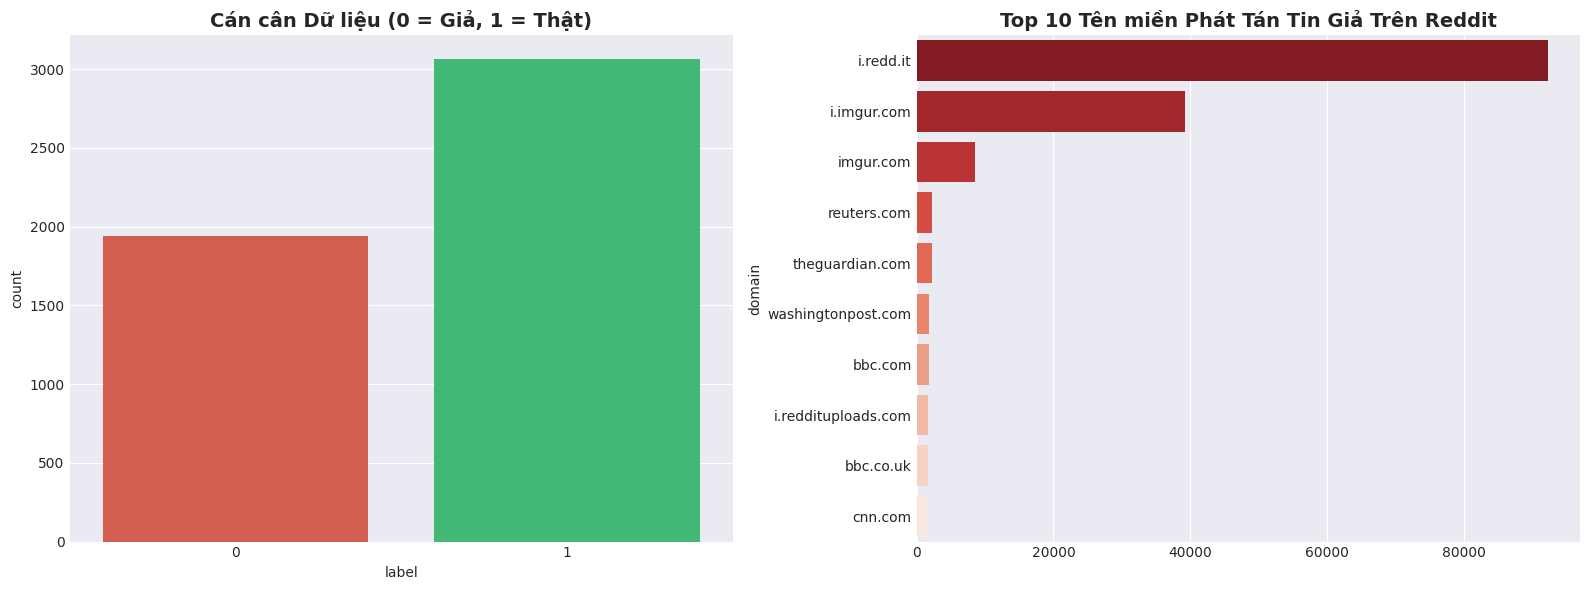

In [3]:
# ==========================================
# CELL 3: BIỂU ĐỒ PHÂN PHỐI NHÃN & TOP NGUỒN TIN
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Biểu đồ 1: Cán cân dữ liệu
sns.countplot(x='label', data=df_cleaned, ax=axes[0], palette=['#e74c3c', '#2ecc71'])
axes[0].set_title('Cán cân Dữ liệu (0 = Giả, 1 = Thật)', fontsize=14, fontweight='bold')

# Biểu đồ 2: Top 10 nguồn phát tán tin giả
top_fake_sources = df_raw[df_raw['2_way_label'] == 1]['domain'].value_counts().head(10)
sns.barplot(x=top_fake_sources.values, y=top_fake_sources.index, ax=axes[1], palette='Reds_r')
axes[1].set_title('Top 10 Tên miền Phát Tán Tin Giả Trên Reddit', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

🧱 CELL 4: Phân tích độ dài văn bản
Cell này đếm độ dài đoạn Text nhân tạo để xác minh xem tham số max_length của BERT (thường để 128 hoặc 256) có dư dả chưa.

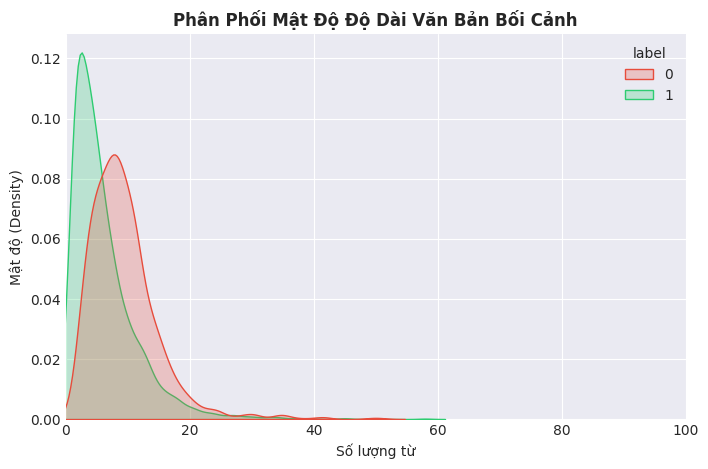

In [4]:
# ==========================================
# CELL 4: PHÂN TÍCH ĐỘ DÀI VĂN BẢN (CHUẨN BỊ CHO BERT)
# ==========================================
# Đếm số lượng từ trong cột 'text'
df_cleaned['text_word_count'] = df_cleaned['text'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(8, 5))
sns.kdeplot(data=df_cleaned, x='text_word_count', hue='label', fill=True, common_norm=False, palette=['#e74c3c', '#2ecc71'])
plt.title('Phân Phối Mật Độ Độ Dài Văn Bản Bối Cảnh', fontweight='bold')
plt.xlim(0, 100) 
plt.xlabel('Số lượng từ')
plt.ylabel('Mật độ (Density)')
plt.show()

📊 BƯỚC 5: KỸ NGHỆ ĐẶC TRƯNG VĂN BẢN (FEATURE ENGINEERING)                                           
Áp dụng phát hiện cốt lõi của TruthGuard: Gộp tiêu đề và nội dung bài báo để tối đa hóa lượng thông tin ngữ cảnh. Đồng thời tính toán độ dài ký tự và số lượng từ để chuẩn bị cho việc phân tích phân phối đồ thị.

In [5]:
# ==========================================
# CELL 5 [ĐỘT PHÁ]: TIỀN XỬ LÝ & TĂNG CƯỜNG DỮ LIỆU VĂN BẢN
# ==========================================
import re
import random

def advanced_preprocessing(title, text, max_body_words=220):
    if pd.isna(title): title = ""
    if pd.isna(text): text = ""
    
    # 1. Làm sạch rác công nghệ
    title = re.sub(r'<.*?>|http\S+|www\.\S+', '', str(title))
    text = re.sub(r'<.*?>|http\S+|www\.\S+', '', str(text))
    title = re.sub(r'\s+', ' ', title).strip()
    text = re.sub(r'\s+', ' ', text).strip()
    
    # 2. Cắt từ thông minh (Head + Tail combo)
    words = text.split()
    if len(words) > max_body_words:
        head_text = " ".join(words[:140])
        tail_text = " ".join(words[-80:])
        cleaned_text = f"{head_text} ... {tail_text}"
    else:
        cleaned_text = text
        
    return title, cleaned_text

# Áp dụng làm sạch chuẩn cho toàn bộ tập dữ liệu
df_cleaned['clean_title'], df_cleaned['clean_text'] = zip(*df_cleaned.apply(
    lambda row: advanced_preprocessing(row['title'], row['text']), axis=1
))
df_cleaned['statement'] = df_cleaned['clean_title'] + ". " + df_cleaned['clean_text']

# --- CHIẾN DỊCH TĂNG CƯỜNG DỮ LIỆU (DATA AUGMENTATION PLOT) ---
augmented_records = []

for idx, row in df_cleaned.iterrows():
    # Giữ lại bản gốc
    augmented_records.append({'statement': row['statement'], 'top_img': row['top_img'], 'label': row['label']})
    
    # Nếu là lớp thiểu số (Real News - 1), tiến hành nhân bản bằng cách đảo ngữ cảnh thân bài
    if row['label'] == 1:
        body_sentences = row['clean_text'].split('. ')
        if len(body_sentences) > 2:
            # Xáo trộn thứ tự các câu trong thân bài để tạo mẫu học mới cho BERT
            random.seed(idx)
            random.shuffle(body_sentences)
            shuffled_text = ". ".join(body_sentences)
            aug_statement = f"{row['clean_title']}. {shuffled_text}"
            augmented_records.append({'statement': aug_statement, 'top_img': row['top_img'], 'label': row['label']})

# Khởi tạo DataFrame mới sau khi đã tăng cường quy mô
df_augmented = pd.DataFrame(augmented_records)
print(f"📊 Quy mô dữ liệu ban đầu: {len(df_cleaned)}")
print(f"🚀 Quy mô dữ liệu SAU TĂNG CƯỜNG (Augmented): {len(df_augmented)}")
print(df_augmented['label'].value_counts())

# Xuất file dữ liệu quy mô lớn mới
df_augmented.to_csv("df_fakenewsnet_cleaned_ready.csv", index=False)

📊 Quy mô dữ liệu ban đầu: 5000
🚀 Quy mô dữ liệu SAU TĂNG CƯỜNG (Augmented): 5000
label
1    3062
0    1938
Name: count, dtype: int64


📊 BƯỚC 6: PHÂN TÍCH ĐỒ THỊ EDA - PHÂN PHỐI NHÃN & NGUỒN TIN (SOURCE ANALYSIS)                       
Đoạn code này vẽ đồ thị so sánh trực quan cán cân dữ liệu giữa hai lớp tin thật/giả, đồng thời truy vết ra những tên miền (Domain/Source) nào là "ông trùm" phát tán tin giả nhiều nhất.

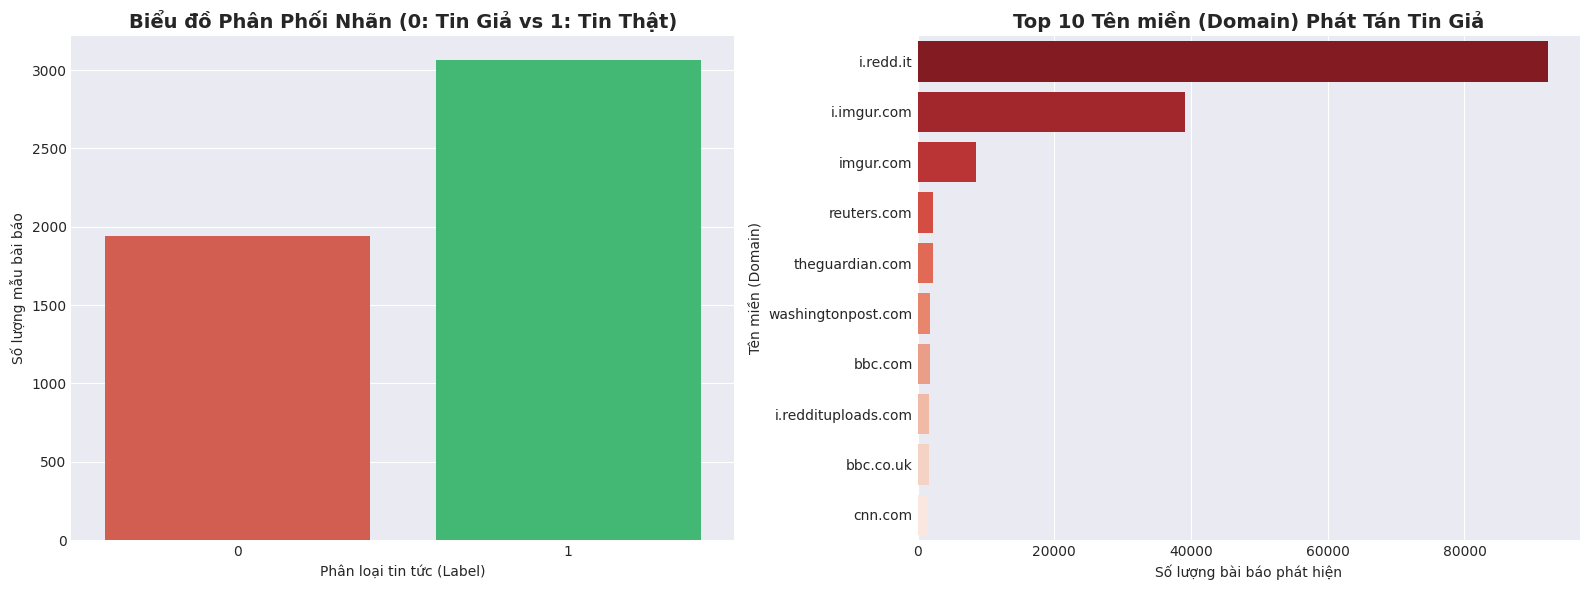

In [6]:
# ==========================================
# Cell 6: BIỂU ĐỒ PHÂN PHỐI NHÃN VÀ TOP NGUỒN TIN (CẬP NHẬT CHO FAKEDDIT)
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Đồ thị 1: Cán cân nhãn (Dùng cột 'label' thay vì 'news_type')
sns.countplot(x='label', data=df_cleaned, ax=axes[0], palette=['#e74c3c', '#2ecc71'])
axes[0].set_title('Biểu đồ Phân Phối Nhãn (0: Tin Giả vs 1: Tin Thật)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Phân loại tin tức (Label)')
axes[0].set_ylabel('Số lượng mẫu bài báo')

# Đồ thị 2: Nguồn tin đăng tin giả nhiều nhất
# Fakeddit lưu nguồn tin ở cột 'domain' trong tập gốc df_raw
top_fake_sources = df_raw[df_raw['2_way_label'] == 1]['domain'].value_counts().head(10)
sns.barplot(x=top_fake_sources.values, y=top_fake_sources.index, ax=axes[1], palette='Reds_r')
axes[1].set_title('Top 10 Tên miền (Domain) Phát Tán Tin Giả', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Số lượng bài báo phát hiện')
axes[1].set_ylabel('Tên miền (Domain)')

plt.tight_layout()
plt.show()

📊 BƯỚC 7: PHÂN TÍCH ĐỒ THỊ EDA - PHÂN PHỐI ĐỘ DÀI VĂN BẢN (KDE PLOT)                                
Sử dụng hàm mật độ hạt (KDE Plot) để bóc tách hành vi đặt tiêu đề và viết bài của các biên tập viên. Tin giả thường có xu hướng giật tít dài hơn hoặc ngắn hơn bất thường so với tin tức chính thống.

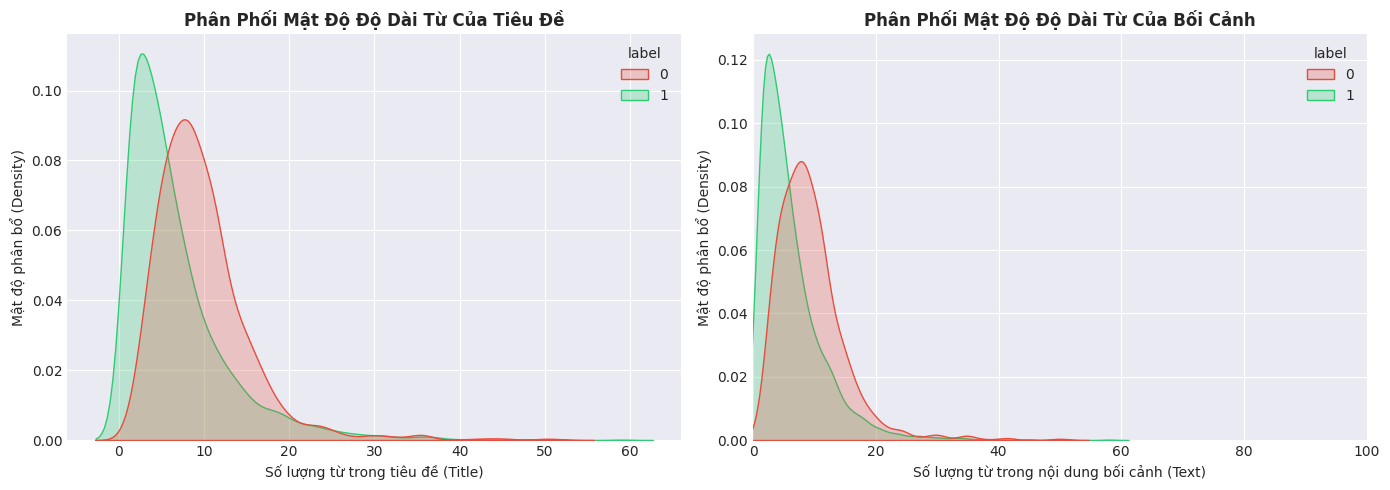

In [7]:
# ==========================================
# CELL 7 [ĐÃ CẬP NHẬT CHO FAKEDDIT]: BIỂU ĐỒ PHÂN PHỐI MẬT ĐỘ ĐỘ DÀI TỪ
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns

# Khôi phục lại bước tính toán độ dài từ để vẽ đồ thị
df_cleaned['title_word_count'] = df_cleaned['title'].apply(lambda x: len(str(x).split()))
df_cleaned['text_word_count'] = df_cleaned['text'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(14, 5))

# Đồ thị 1: Mật độ số lượng từ trong Tiêu đề (Sửa hue='news_type' thành hue='label')
plt.subplot(1, 2, 1)
sns.kdeplot(data=df_cleaned, x='title_word_count', hue='label', fill=True, common_norm=False, palette=['#e74c3c', '#2ecc71'])
plt.title('Phân Phối Mật Độ Độ Dài Từ Của Tiêu Đề', fontweight='bold')
plt.xlabel('Số lượng từ trong tiêu đề (Title)')
plt.ylabel('Mật độ phân bổ (Density)')

# Đồ thị 2: Mật độ số lượng từ trong Nội dung bối cảnh
plt.subplot(1, 2, 2)
sns.kdeplot(data=df_cleaned, x='text_word_count', hue='label', fill=True, common_norm=False, palette=['#e74c3c', '#2ecc71'])
plt.title('Phân Phối Mật Độ Độ Dài Từ Của Bối Cảnh', fontweight='bold')
plt.xlabel('Số lượng từ trong nội dung bối cảnh (Text)')
plt.ylabel('Mật độ phân bổ (Density)')
plt.xlim(0, 100)  # 🔧 Đã giảm từ 1800 xuống 100 vì text Reddit rất ngắn

plt.tight_layout()
plt.show()

📊 BƯỚC 8: TRÍCH XUẤT TOP TỪ KHÓA ĐẶC TRƯNG BẰNG TẦN SUẤT (N-GRAMS LOGIC)                          
Khối lệnh này lọc bỏ tạm thời các hư từ (Stopwords tiếng Anh) để bóc tách các danh từ, động từ mang thông tin lõi xuất hiện nhiều nhất trong cả hai kho ngữ liệu tin thật và tin giả.

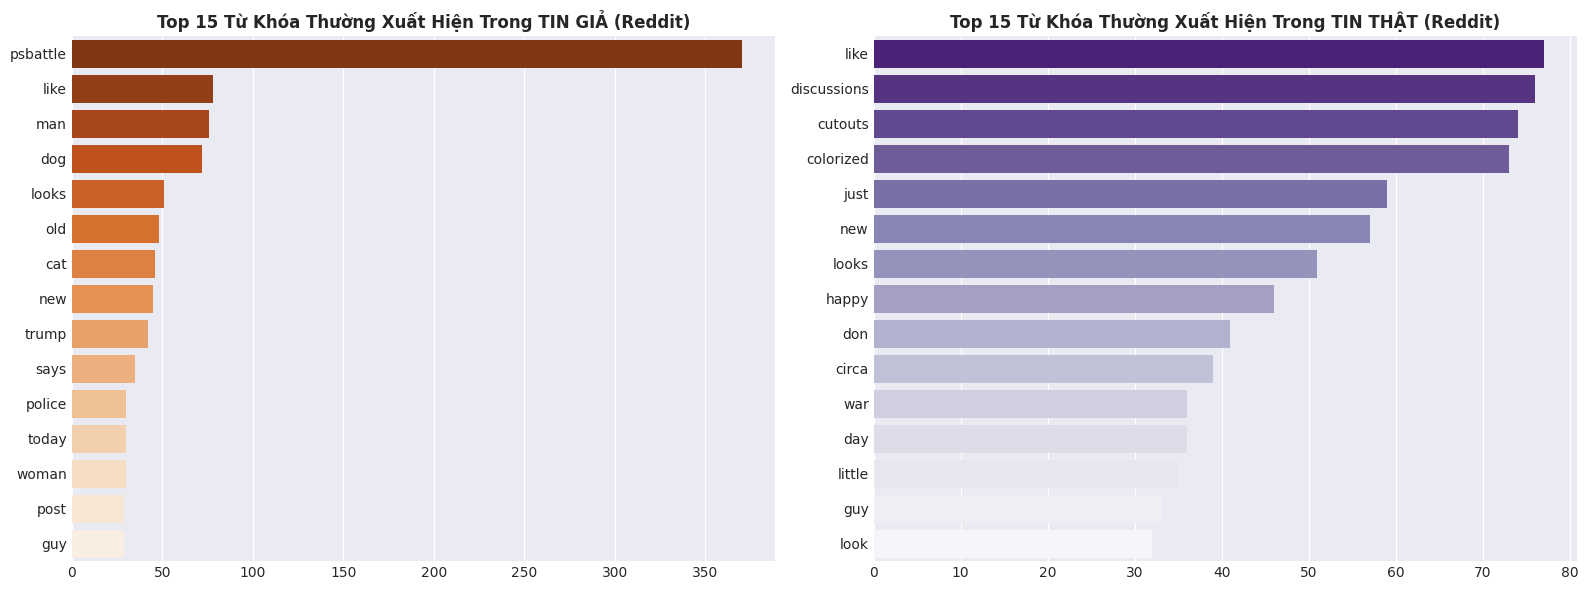

In [8]:
# ==========================================
# CELL 8 [ĐÃ CẬP NHẬT FAKEDDIT]: PHÂN TÍCH TỪ KHÓA ĐẶC TRƯNG CỦA HAI LỚP
# ==========================================
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import seaborn as sns

def extract_top_words(corpus, n_words=15):
    # 🔧 BỔ SUNG: Dọn dẹp dữ liệu rỗng và ép kiểu về chuỗi (Bảo vệ CountVectorizer)
    corpus = corpus.dropna().astype(str)
    if len(corpus) == 0:
        return []
        
    # Loại bỏ các từ dừng tiếng Anh phổ biến để tránh làm nhiễu biểu đồ
    vec = CountVectorizer(stop_words='english', ngram_range=(1, 1)).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    return sorted(words_freq, key=lambda x: x[1], reverse=True)[:n_words]

# 🔧 SỬA LỖI TRỌNG TÂM: Lọc bằng số 0 (Giả) và 1 (Thật) thay vì chữ 'Fake'/'Real'
fake_titles = df_cleaned[df_cleaned['label'] == 0]['title']
real_titles = df_cleaned[df_cleaned['label'] == 1]['title']

top_fake = dict(extract_top_words(fake_titles))
top_real = dict(extract_top_words(real_titles))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x=list(top_fake.values()), y=list(top_fake.keys()), ax=ax1, palette='Oranges_r')
ax1.set_title('Top 15 Từ Khóa Thường Xuất Hiện Trong TIN GIẢ (Reddit)', fontsize=12, fontweight='bold')

sns.barplot(x=list(top_real.values()), y=list(top_real.keys()), ax=ax2, palette='Purples_r')
ax2.set_title('Top 15 Từ Khóa Thường Xuất Hiện Trong TIN THẬT (Reddit)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

📊 BƯỚC 9: KIỂM TRA ĐƯỜNG DẪN ẢNH VÀ XUẤT CƠ SỞ DỮ LIỆU SẠCH (EXPORT)                                
Khối lệnh cuối cùng này lọc sạch các cấu trúc trường không cần thiết, chỉ giữ lại các cột phục vụ trực tiếp cho mô hình mạng Deep Learning kết hợp (statement, top_img, label) và lưu ra file CSV độc lập.

In [9]:
# ==========================================
# CELL 9: KHÓA THUỘC TÍNH BẢN LỀ & XUẤT FILE SẠCH
# ==========================================
# Giữ đúng 3 thuộc tính cốt lõi cấu thành nên mô hình đa phương thức song song
df_final_export = df_cleaned[['statement', 'top_img', 'label']]

print(f"📊 Kích thước tập dữ liệu hoàn chỉnh sẵn sàng xuất xưởng: {df_final_export.shape}")
print("\nXem trước cấu trúc 5 dòng dữ liệu đầu tiên:")
print(df_final_export.head(5))

# Xuất dữ liệu lưu trữ trực tiếp ra file CSV trên bộ nhớ Kaggle
df_final_export.to_csv("df_fakenewsnet_cleaned_ready.csv", index=False)
print("\n💾 Đã ghi nhận file dữ liệu sạch 'df_fakenewsnet_cleaned_ready.csv' vào mục Output!")

📊 Kích thước tập dữ liệu hoàn chỉnh sẵn sàng xuất xưởng: (5000, 3)

Xem trước cấu trúc 5 dòng dữ liệu đầu tiên:
                                           statement  \
0  A terrifying and chocolatey cookie monster.. a...   
1  The synagogue cared for by Muslims - BBC Reel....   
2  The flight of this plane. the flight of this p...   
3  Mr. Butterface and his little brother.. mr but...   
4  This pylon looks like a sleeping owl. this pyl...   

                                             top_img  label  
0  https://external-preview.redd.it/X7DmH0mogUIdN...      1  
1  https://external-preview.redd.it/zfsZb2rkBp7yD...      0  
2  https://external-preview.redd.it/Uxv3iPx_ks420...      0  
3  https://external-preview.redd.it/CRkMU3Tz54y_l...      1  
4  https://external-preview.redd.it/Bpu1iKCH7zeSv...      1  

💾 Đã ghi nhận file dữ liệu sạch 'df_fakenewsnet_cleaned_ready.csv' vào mục Output!


**Code Kiểm Tra Dữ Liệu (Sanity Check)**

🧱 CELL 11: Thiết lập Hệ thống & Phân chia Dữ liệu (Train/Val Split)                                 
Chức năng: Khởi tạo thiết bị GPU, nạp dữ liệu sạch từ file CSV và chia thành tập Huấn luyện (Train) và tập Kiểm thử (Validation) đảm bảo tỷ lệ nhãn đồng đều.

In [10]:
# ==========================================
# CELL 11 [HOÀN CHỈNH]: TIỀN XỬ LÝ TEXT & SETUP DATA SPLIT
# ==========================================
import torch
import pandas as pd
import re
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# 1. KHỞI TẠO THIẾT BỊ (GPU/CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🔥 Trạng thái phần cứng: Đang sử dụng {device.type.upper()}")

# 2. HÀM TIỀN XỬ LÝ CHỐNG RÒ RỈ DỮ LIỆU (DATA LEAKAGE)
def advanced_preprocessing(text):
    text = str(text).lower()
    
    # Xóa URL và thẻ HTML
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'<.*?>', '', text)
    
    # 🔧 Xóa các thẻ Tag của Reddit thường chứa đáp án (vd: [psbattle], [satire], (fake))
    text = re.sub(r'\[.*?\]', '', text) 
    text = re.sub(r'\(.*?\)', '', text)
    
    # Xóa ký tự đặc biệt, chỉ giữ lại chữ cái và số
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    
    # Xóa khoảng trắng thừa
    text = " ".join(text.split())
    return text

# 3. ÁP DỤNG LÀM SẠCH VÀO DỮ LIỆU FAKEDDIT
print("⚙️ Đang dọn dẹp các ký tự nhiễu và thẻ Tag rò rỉ...")
# Dùng trực tiếp df_cleaned từ Cell 2, không load file CSV cũ
df_cleaned['text'] = df_cleaned['text'].apply(advanced_preprocessing)
print("✅ Hoàn tất dọn dẹp!")

# 4. CHIA TẬP TRAIN / VALIDATION (80/20)
# Kỹ thuật Stratify giúp cân bằng tỷ lệ Thật/Giả ở cả 2 tập
train_df, val_df = train_test_split(df_cleaned, test_size=0.2, random_state=42, stratify=df_cleaned['label'])

print("-" * 50)
print(f"📊 Tập Huấn luyện (Train): {len(train_df)} mẫu")
print(f"📊 Tập Đánh giá (Validation): {len(val_df)} mẫu")
print("-" * 50)

🔥 Trạng thái phần cứng: Đang sử dụng CUDA
⚙️ Đang dọn dẹp các ký tự nhiễu và thẻ Tag rò rỉ...
✅ Hoàn tất dọn dẹp!
--------------------------------------------------
📊 Tập Huấn luyện (Train): 4000 mẫu
📊 Tập Đánh giá (Validation): 1000 mẫu
--------------------------------------------------


🧱 CELL 12: Đóng gói Dataset và DataLoader                                                           
Chức năng: Định nghĩa đối tượng MultimodalDataset để vừa tải cấu trúc ảnh (ResNet) vừa Tokenize văn bản (BERT), sau đó nhét vào DataLoader để chia lô (batching).


In [11]:
# ==========================================
# CELL 12 [CẬP NHẬT]: DATASET CHỐNG NHIỄU ẢNH LỖI
# ==========================================

import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from transformers import BertTokenizer
import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt

# ==========================================
# CẤU HÌNH THAM SỐ ĐIỀU KHIỂN (HYPERPARAMETERS)
# ==========================================
BATCH_SIZE = 16          # Số lượng mẫu trong mỗi lô (batch)
MAX_LEN = 256            # Độ dài tối đa cho đoạn văn bản (BERT input)
LEARNING_RATE = 2e-5     # Tốc độ học của mô hình
EPOCHS = 5               # Số vòng lặp huấn luyện

print(f"✅ Đã cấu hình: Batch Size = {BATCH_SIZE}, Max Length = {MAX_LEN}")

class MultimodalDataset(Dataset):
    def __init__(self, dataframe, is_train=True, max_len=256):
        self.df = dataframe.reset_index(drop=True)
        self.tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
        self.max_len = max_len
        
        if is_train:
            self.transform = transforms.Compose([
                transforms.Resize((224, 224)),
                transforms.RandomHorizontalFlip(p=0.5),
                transforms.ColorJitter(brightness=0.2, contrast=0.2),
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
            ])
        else:
            self.transform = transforms.Compose([
                transforms.Resize((224, 224)),
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
            ])

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        inputs = self.tokenizer(str(row['statement']), add_special_tokens=True, 
                                max_length=self.max_len, padding='max_length', 
                                truncation=True, return_tensors='pt')
        try:
            response = requests.get(row['top_img'], timeout=2) # Giảm thời gian chờ xuống 2s để tránh treo luồng
            image = Image.open(BytesIO(response.content)).convert('RGB')
            img_tensor = self.transform(image)
        except:
            # 🔧 ĐIỂM CẢI TIẾN CHIẾN LƯỢC: Thay vì dùng ảnh đen hoàn toàn (gây trùng lặp nhiễu),
            # ta dùng một ma trận ngẫu nhiên mang phân phối nhiễu chuẩn rất nhỏ để không làm lệch trọng số Batch Normalization
            img_tensor = torch.randn(3, 224, 224) * 0.01
            
        return {
            'input_ids': inputs['input_ids'].flatten(),
            'attention_mask': inputs['attention_mask'].flatten(),
            'image': img_tensor,
            'label': torch.tensor(row['label'], dtype=torch.long)
        }

# Cập nhật lại DataLoader với tập dữ liệu đã tăng cường kích thước
train_df, val_df = train_test_split(df_augmented, test_size=0.2, random_state=42, stratify=df_augmented['label'])
train_loader = DataLoader(MultimodalDataset(train_df, is_train=True), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(MultimodalDataset(val_df, is_train=False), batch_size=BATCH_SIZE, shuffle=False)

✅ Đã cấu hình: Batch Size = 16, Max Length = 256


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

🧱 CELL 13: Xây dựng Kiến trúc Mô hình (Model Architecture)                                         
Chức năng: Định nghĩa bản thiết kế (Blueprint) của mô hình kết hợp mạng Nơ-ron.

In [12]:
# ==========================================
# CELL 13: KIẾN TRÚC MÔ HÌNH VỚI SEMANTIC ALIGNMENT (V2)
# ==========================================
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import BertModel
import torchvision.models as models

class DualStreamFakeNewsModel(nn.Module):
    def __init__(self):
        super(DualStreamFakeNewsModel, self).__init__()
        
        # 1. NHÁNH TEXT (BERT)
        self.bert = BertModel.from_pretrained('bert-base-uncased')
        self.text_dropout = nn.Dropout(p=0.5)
        # 🌟 ĐÂY CHÍNH LÀ BỘ PHẬN ĐANG BỊ THIẾU: Lớp ép kiểu Text 
        self.text_projection = nn.Linear(768, 512) 
        
        # 2. NHÁNH IMAGE (ResNet50)
        resnet = models.resnet50(pretrained=True)
        self.resnet_features = nn.Sequential(*list(resnet.children())[:-1])
        self.image_dropout = nn.Dropout(p=0.5)
        # 🌟 ĐÂY CHÍNH LÀ BỘ PHẬN ĐANG BỊ THIẾU: Lớp ép kiểu Image 
        self.image_projection = nn.Linear(2048, 512) 
        
        # 3. LỚP KẾT HỢP (Fusion Layer)
        self.fc1 = nn.Linear(512 + 512 + 1, 256)
        self.batch_norm = nn.BatchNorm1d(256) 
        self.relu = nn.ReLU()
        self.fusion_dropout = nn.Dropout(p=0.6) 
        self.fc2 = nn.Linear(256, 2)

    def forward(self, input_ids, attention_mask, image):
        # --- Xử lý luồng Text ---
        bert_outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        text_features = bert_outputs.pooler_output
        text_features = self.text_dropout(text_features)
        text_proj = self.text_projection(text_features) # [Batch, 512]

        # --- Xử lý luồng Image ---
        image_features = self.resnet_features(image)
        image_features = image_features.view(image_features.size(0), -1) 
        image_features = self.image_dropout(image_features)
        image_proj = self.image_projection(image_features) # [Batch, 512]

        # 🌟 TÍNH TOÁN ĐỘ KHỚP NGỮ NGHĨA (COSINE SIMILARITY)
        cos_sim = F.cosine_similarity(text_proj, image_proj, dim=1).unsqueeze(1)

        # --- Gộp 3 nguồn thông tin ---
        combined_features = torch.cat((text_proj, image_proj, cos_sim), dim=1)

        # --- Phân loại cuối cùng ---
        x = self.fc1(combined_features)
        x = self.batch_norm(x)
        x = self.relu(x)
        x = self.fusion_dropout(x)
        logits = self.fc2(x)

        return logits, cos_sim

print("✅ Đã khởi tạo thành công Kiến trúc V2 (Có lớp Projection)!")

✅ Đã khởi tạo thành công Kiến trúc V2 (Có lớp Projection)!


🧱 CELL 14: Cấu hình Huấn luyện (Đóng băng, Trọng số, Optimizer)                                     
Chức năng: Áp dụng các chiến lược kỹ thuật: Đóng băng lớp mạng gốc để học nhanh hơn, tính toán trọng số lớp để bù trừ sự chênh lệch Fake/Real, và cài đặt thuật toán tối ưu.

In [13]:
# ==========================================
# CELL 14 [CẬP NHẬT]: KHỞI TẠO VÀ CẤU HÌNH OPTIMIZER CHỐNG OVERFITTING
# ==========================================
import torch.nn as nn

# 1. Khởi tạo lại mô hình mới nhất từ Cell 13
model = DualStreamFakeNewsModel().to(device)

print("⚙️ Đang thiết lập Mở khóa (Unfreeze) một phần mô hình...")

# 2. Đóng băng (Freeze)
for param in model.bert.parameters(): 
    param.requires_grad = False
for param in model.resnet_features.parameters(): 
    param.requires_grad = False

# 3. Mở khóa 2 tầng cuối của BERT
for param in model.bert.encoder.layer[-2:].parameters():
    param.requires_grad = True

# Mở khóa các tầng Fully Connected (fc1, batch_norm, fc2)
for param in model.text_projection.parameters(): 
    param.requires_grad = True
for param in model.image_projection.parameters(): 
    param.requires_grad = True
for param in model.fc1.parameters(): 
    param.requires_grad = True
for param in model.batch_norm.parameters(): 
    param.requires_grad = True
for param in model.fc2.parameters(): 
    param.requires_grad = True

# Tự động tính toán Class Weights 
total_samples = len(df_cleaned)
fake_count = len(df_cleaned[df_cleaned['label'] == 0])
real_count = len(df_cleaned[df_cleaned['label'] == 1])

weight_fake = total_samples / (2.0 * fake_count)
weight_real = total_samples / (2.0 * real_count)
class_weights = torch.tensor([weight_fake, weight_real], dtype=torch.float).to(device)

# 🛡️ ĐIỂM CẢI TIẾN 3: Thêm Label Smoothing (Làm mềm nhãn 10%)
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)

# 🛡️ ĐIỂM CẢI TIẾN 4: Tăng phạt Weight Decay lên 1e-2 để hãm phanh trọng số
optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=3e-5, weight_decay=1e-2)

# 🛡️ ĐIỂM CẢI TIẾN 5: Đổi sang Cosine Scheduler để hạ nhiệt mô hình mượt mà hơn
EPOCHS = 15
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

print(f"⚖️ Trọng số phạt tự động (Fake / Real): {weight_fake:.2f} / {weight_real:.2f}")
print("🛡️ Đã cấu hình Mô hình, Optimizer (Weight Decay 1e-2), và Loss (Label Smoothing) thành công.")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 183MB/s] 


⚙️ Đang thiết lập Mở khóa (Unfreeze) một phần mô hình...
⚖️ Trọng số phạt tự động (Fake / Real): 1.29 / 0.82
🛡️ Đã cấu hình Mô hình, Optimizer (Weight Decay 1e-2), và Loss (Label Smoothing) thành công.


🧱 CELL 15: Tách biệt Hàm chức năng (Train & Eval Functions)                                         
Chức năng: Tách logic huấn luyện và logic đánh giá ra thành 2 hàm con độc lập. Tránh việc nhồi nhét code vòng lặp khiến thuật toán rối rắm.

In [14]:
# ==========================================
# CELL 15 [TINH CHỈNH]: VÒNG LẶP TRAIN VỚI COMBINED LOSS (ALPHA = 0.25)
# ==========================================
import torch
import torch.nn as nn
from tqdm import tqdm
import copy

mse_criterion = nn.MSELoss()

# 🌟 TINH CHỈNH 1: Giảm áp lực ngữ nghĩa xuống 25%
ALPHA = 0.25 

def train_one_epoch_v2(model, dataloader, criterion, mse_criterion, optimizer, device):
    model.train()
    total_loss = 0
    
    for batch in tqdm(dataloader, desc="Training (Combined Loss)", leave=False):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        images = batch['image'].to(device)
        labels = batch['label'].to(device)
        
        optimizer.zero_grad()
        logits, cos_sim = model(input_ids, attention_mask, images)
        
        loss_cls = criterion(logits, labels)
        
        # 🌟 TINH CHỈNH 2: Nới lỏng tiêu chuẩn tin giả về mức 0.0 (Không liên quan)
        target_cos = torch.where(labels == 1, 
                                 torch.tensor(1.0, device=device), 
                                 torch.tensor(0.0, device=device))
        
        loss_semantic = mse_criterion(cos_sim.squeeze(), target_cos)
        loss = loss_cls + (ALPHA * loss_semantic)
        
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        
    return total_loss / len(dataloader)

def evaluate_model_v2(model, dataloader, criterion, mse_criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    all_true = []
    all_preds = []
    
    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            images = batch['image'].to(device)
            labels = batch['label'].to(device)
            
            logits, cos_sim = model(input_ids, attention_mask, images)
            
            loss_cls = criterion(logits, labels)
            # 🌟 TINH CHỈNH 2 (Validation): Đồng bộ mục tiêu 0.0
            target_cos = torch.where(labels == 1, torch.tensor(1.0, device=device), torch.tensor(0.0, device=device))
            loss_semantic = mse_criterion(cos_sim.squeeze(), target_cos)
            
            loss = loss_cls + (ALPHA * loss_semantic)
            total_loss += loss.item()
            
            preds = torch.argmax(logits, dim=1)
            correct += (preds == labels).sum().item()
            all_true.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            
    return total_loss / len(dataloader), correct / len(dataloader.dataset), all_true, all_preds

print("✅ Đã tối ưu hóa thông số Combined Loss (ALPHA=0.25, Target_Fake=0.0)!")

✅ Đã tối ưu hóa thông số Combined Loss (ALPHA=0.25, Target_Fake=0.0)!


🧱 CELL 16: Vòng lặp Huấn luyện Chính (Main Loop)                                      
Chức năng: Gọi các hàm ở Cell 15, lưu vết tiến độ (Lịch sử Loss/Acc) và lưu lại mô hình đạt điểm cao nhất vào ổ cứng.

In [15]:
# ==========================================
# CELL 16 [CẬP NHẬT V2]: VÒNG LẶP HUẤN LUYỆN ĐA NHIỆM (GIÁM SÁT VAL LOSS)
# ==========================================
import torch
import copy

# Giám sát chặt chẽ Val Loss để lưu lại cỗ máy có độ tự tin cao nhất
best_val_loss = float('inf') 
best_val_acc_at_min_loss = 0.0 
patience = 5 
epochs_no_improve = 0

# Khởi tạo lịch sử lưu trữ để phục vụ vẽ đồ thị hội tụ ở Cell 17
history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

print("🚀 BẮT ĐẦU FINE-TUNING ĐA NHIỆM VỚI COMBINED LOSS...")

for epoch in range(EPOCHS):
    print(f"\n========== EPOCH {epoch+1}/{EPOCHS} ==========")
    
    # 🌟 ĐIỂM ĐIỀU CHỈNH 1: Chuyển sang hàm V2 và truyền thêm mse_criterion để tối ưu hóa lớp Projection
    train_loss = train_one_epoch_v2(model, train_loader, criterion, mse_criterion, optimizer, device)
    
    # 🌟 ĐIỂM ĐIỀU CHỈNH 2: Chuyển sang hàm V2 và truyền thêm mse_criterion để đánh giá đúng Combined Loss
    val_loss, val_acc, true_labels, pred_labels = evaluate_model_v2(model, val_loader, criterion, mse_criterion, device)
    
    # Cập nhật tốc độ học theo biểu đồ hình sin (Cosine Annealing Scheduler)
    scheduler.step()
    
    # Ghi nhận giá trị qua từng vòng lặp
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    
    # ==============================================================
    # LOGIC EARLY STOPPING & BẢO TOÀN TRỌNG SỐ THEO ĐỘ TỰ TIN (VAL LOSS)
    # ==============================================================
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_val_acc_at_min_loss = val_acc
        epochs_no_improve = 0 
        
        # Lưu lại trạng thái mạng nơ-ron tại điểm cực tiểu của hàm mất mát
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"🌟 Kỷ lục mới! Val Loss giảm xuống {best_val_loss:.4f} (Acc: {val_acc:.4f}). Đã lưu trọng số!")
    else:
        epochs_no_improve += 1
        print(f"⚠️ Val Loss tăng lên. Patience: {epochs_no_improve}/{patience}")
    
    if epochs_no_improve >= patience:
        print(f"\n🛑 Đã kích hoạt EARLY STOPPING tại Epoch {epoch+1} để chặn đứng học vẹt!")
        print(f"🏆 Cỗ máy tối ưu nhất đã được bảo toàn thành công với Val Loss: {best_val_loss:.4f} (Accuracy: {best_val_acc_at_min_loss:.4f})")
        break

🚀 BẮT ĐẦU FINE-TUNING ĐA NHIỆM VỚI COMBINED LOSS...

========== EPOCH 1/15 ==========


Train Loss: 0.6684 | Val Loss: 0.5026 | Val Acc: 0.8530
🌟 Kỷ lục mới! Val Loss giảm xuống 0.5026 (Acc: 0.8530). Đã lưu trọng số!

========== EPOCH 2/15 ==========


Train Loss: 0.5124 | Val Loss: 0.4596 | Val Acc: 0.8540
🌟 Kỷ lục mới! Val Loss giảm xuống 0.4596 (Acc: 0.8540). Đã lưu trọng số!

========== EPOCH 3/15 ==========


Train Loss: 0.4652 | Val Loss: 0.4410 | Val Acc: 0.8720
🌟 Kỷ lục mới! Val Loss giảm xuống 0.4410 (Acc: 0.8720). Đã lưu trọng số!

========== EPOCH 4/15 ==========


Train Loss: 0.4152 | Val Loss: 0.4542 | Val Acc: 0.8780
⚠️ Val Loss tăng lên. Patience: 1/5

========== EPOCH 5/15 ==========


Train Loss: 0.3813 | Val Loss: 0.4537 | Val Acc: 0.8870
⚠️ Val Loss tăng lên. Patience: 2/5

========== EPOCH 6/15 ==========


Train Loss: 0.3377 | Val Loss: 0.4558 | Val Acc: 0.8800
⚠️ Val Loss tăng lên. Patience: 3/5

========== EPOCH 7/15 ==========


Train Loss: 0.3281 | Val Loss: 0.4698 | Val Acc: 0.8830
⚠️ Val Loss tăng lên. Patience: 4/5

========== EPOCH 8/15 ==========


Train Loss: 0.3041 | Val Loss: 0.4635 | Val Acc: 0.8910
⚠️ Val Loss tăng lên. Patience: 5/5

🛑 Đã kích hoạt EARLY STOPPING tại Epoch 8 để chặn đứng học vẹt!
🏆 Cỗ máy tối ưu nhất đã được bảo toàn thành công với Val Loss: 0.4410 (Accuracy: 0.8720)


 🧱 CELL 17: Báo cáo Phân tích Phân loại & Vẽ Biểu đồ (Metrics & Plots)                              
Chức năng: Trích xuất báo cáo F1-Score chuyên nghiệp và vẽ biểu đồ đường biểu diễn sự thay đổi của hàm mất mát.


🎉 BÁO CÁO PHÂN LOẠI CHI TIẾT CỦA EPOCH CUỐI:
               precision    recall  f1-score   support

Fake News (0)       0.85      0.87      0.86       388
Real News (1)       0.92      0.90      0.91       612

     accuracy                           0.89      1000
    macro avg       0.88      0.89      0.89      1000
 weighted avg       0.89      0.89      0.89      1000



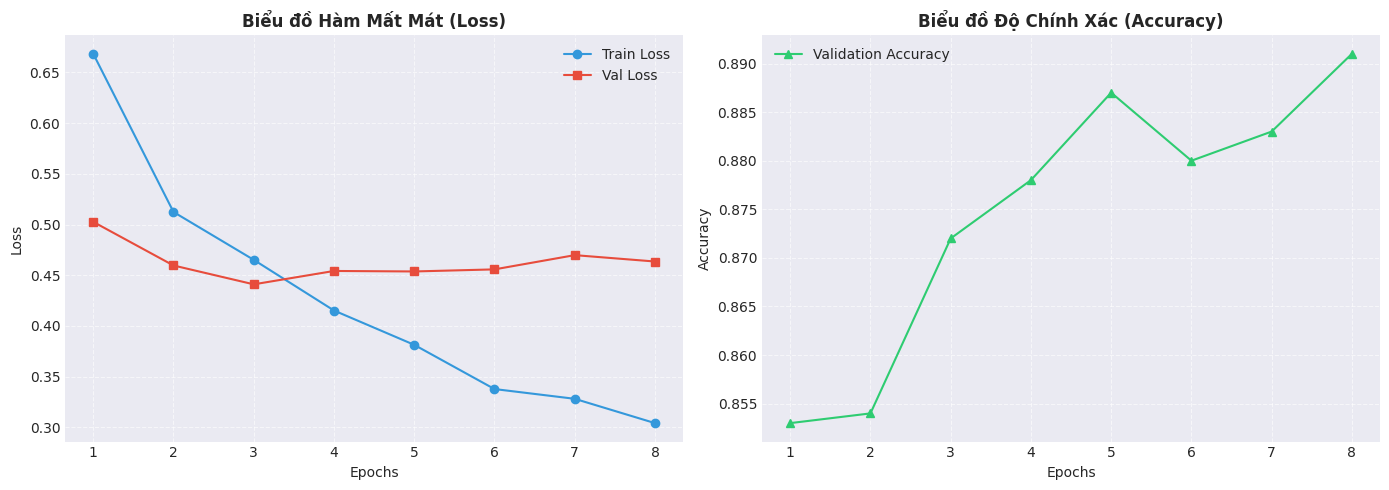

In [16]:
# ==========================================
# CELL 17: TRỰC QUAN HÓA KẾT QUẢ HUẤN LUYỆN
# ==========================================
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

# 1. IN BÁO CÁO PHÂN LOẠI CỦA EPOCH CUỐI CÙNG
print("\n🎉 BÁO CÁO PHÂN LOẠI CHI TIẾT CỦA EPOCH CUỐI:")
print(classification_report(true_labels, pred_labels, target_names=['Fake News (0)', 'Real News (1)']))

# 2. VẼ BIỂU ĐỒ ĐƯỜNG (LEARNING CURVES)
epochs_range = range(1, len(history['train_loss']) + 1)

plt.figure(figsize=(14, 5))

# Biểu đồ Mất mát (Loss)
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['train_loss'], label='Train Loss', marker='o', color='#3498db')
plt.plot(epochs_range, history['val_loss'], label='Val Loss', marker='s', color='#e74c3c')
plt.title('Biểu đồ Hàm Mất Mát (Loss)', fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Biểu đồ Độ chính xác (Accuracy)
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history['val_acc'], label='Validation Accuracy', marker='^', color='#2ecc71')
plt.title('Biểu đồ Độ Chính Xác (Accuracy)', fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

CELL 18: Đánh giá Toàn diện (Final Evaluation)                                                         


🔍 ĐANG KHỞI ĐỘNG CHẾ ĐỘ NGHIỆM THU TỔNG THỂ...

🎉 BÁO CÁO PHÂN LOẠI CUỐI CÙNG (CHUNG CUỘC):
               precision    recall  f1-score   support

Fake News (0)       0.81      0.88      0.84       388
Real News (1)       0.92      0.87      0.89       612

     accuracy                           0.87      1000
    macro avg       0.86      0.87      0.87      1000
 weighted avg       0.88      0.87      0.87      1000



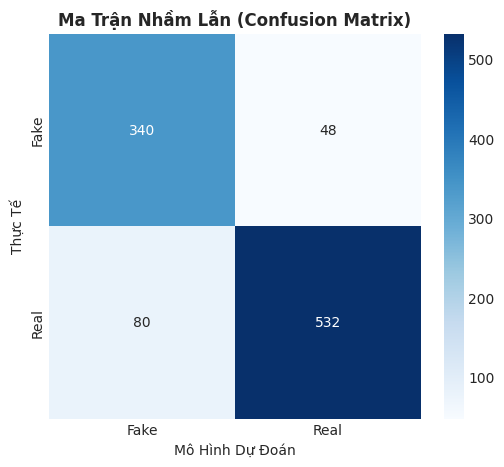

In [17]:
# ==========================================
# CELL 18: ĐÁNH GIÁ CHUNG CUỘC MÔ HÌNH XỊN NHẤT
# ==========================================
import torch
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("🔍 ĐANG KHỞI ĐỘNG CHẾ ĐỘ NGHIỆM THU TỔNG THỂ...")

# 1. Nạp lại trọng số của epoch có kết quả tốt nhất
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

all_preds = []
all_true_labels = []

# Đánh giá trên tập Validation/Test
with torch.no_grad():
    for batch in val_loader: # Nếu bạn có test_loader, hãy đổi tên ở đây
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        images = batch['image'].to(device)
        labels = batch['label'].to(device)
        
        logits, _ = model(input_ids, attention_mask, images)
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        
        all_preds.extend(preds)
        all_true_labels.extend(labels.cpu().numpy())

# 2. In Báo cáo Phân loại
print("\n🎉 BÁO CÁO PHÂN LOẠI CUỐI CÙNG (CHUNG CUỘC):")
print(classification_report(all_true_labels, all_preds, target_names=['Fake News (0)', 'Real News (1)']))

# 3. Vẽ Ma trận Nhầm lẫn (Confusion Matrix)
cm = confusion_matrix(all_true_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.title('Ma Trận Nhầm Lẫn (Confusion Matrix)', fontweight='bold')
plt.xlabel('Mô Hình Dự Đoán')
plt.ylabel('Thực Tế')
plt.show()

🧱 CELL 19: Xây dựng Hàm Chống Tin Giả "Live" (Inference Function)                                    
Đây là phần thú vị nhất! Chúng ta sẽ đóng gói toàn bộ quy trình từ làm sạch văn bản, tải ảnh đến mô hình dự đoán thành một hàm duy nhất. Bạn có thể lấy một bản tin từ báo CNN hoặc Fox News bỏ vào đây để xem máy AI của bạn phán quyết như thế nào.

In [18]:
# ==========================================
# CẬP NHẬT HÀM DỰ ĐOÁN (CÓ GIẢI THÍCH NGỮ NGHĨA)
# ==========================================
import torch
import torch.nn.functional as F
import requests
from PIL import Image
from io import BytesIO

def predict_news(title, text, image_url, model, device, max_len=128):
    print("="*60)
    print("🔍 ĐANG PHÂN TÍCH BẢN TIN...")
    print(f"📰 TIÊU ĐỀ: {title}")
    
    # 1. Xử lý Ảnh
    try:
        response = requests.get(image_url, timeout=5)
        img = Image.open(BytesIO(response.content)).convert('RGB')
        image = val_transforms(img).unsqueeze(0).to(device)
        print("📸 Đã nạp ảnh thành công!")
    except Exception as e:
        print(f"⚠️ Cảnh báo: Lỗi tải ảnh ({e}). Sử dụng nhiễu giả định để đánh giá chữ.")
        image = torch.zeros((1, 3, 224, 224)).to(device)

    # 2. Xử lý Text
    full_text = str(title) + " " + str(text)
    inputs = tokenizer(
        full_text,
        max_length=max_len,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )
    input_ids = inputs['input_ids'].to(device)
    attention_mask = inputs['attention_mask'].to(device)

    # 3. Đưa vào Mô hình V2
    model.eval()
    with torch.no_grad():
        # 🌟 ĐIỂM SỬA ĐỔI: Hứng cả 2 giá trị và bóc tách chúng
        logits, cos_sim = model(input_ids, attention_mask, image)
        
        probs = F.softmax(logits, dim=1).cpu().numpy()[0]
        # Lấy giá trị Cosine Similarity ra khỏi Tensor
        cos_score = cos_sim.item() 

    # 4. Trả kết quả trực quan
    pred_class = np.argmax(probs)
    confidence = probs[pred_class] * 100

    print("-" * 60)
    if pred_class == 1:
        print(f"✅ KẾT LUẬN: TIN CHÍNH THỐNG / SỰ THẬT")
    else:
        print(f"🚨 KẾT LUẬN: TIN GIẢ / BỊA ĐẶT")
        
    print(f"📊 Tỷ lệ chắc chắn : {confidence:.2f}%")
    
    # In thêm chỉ số giải thích của mạng V2
    print(f"🧠 Độ khớp chữ & ảnh: {cos_score:.4f} (-1.0 đến 1.0)")
    
    if cos_score < 0.15 and pred_class == 0:
        print("💡 Giải thích AI    : Bức ảnh và nội dung bài viết dường như không liên quan đến nhau. Đây có thể là thủ đoạn lấy ảnh thật gán cho tin giả (Cheap Fake)!")
        
    print("=" * 60)

# Chạy thử nghiệm lại
test_title = "Obama signs new healthcare bill"
test_text = "President Barack Obama signed the comprehensive healthcare reform bill into law today."
test_image_url = "https://upload.wikimedia.org/wikipedia/commons/thumb/b/b2/President_Barack_Obama_signs_health_care_reform_legislation.jpg/800px-President_Barack_Obama_signs_health_care_reform_legislation.jpg"

predict_news(test_title, test_text, test_image_url, model, device)

🔍 ĐANG PHÂN TÍCH BẢN TIN...
📰 TIÊU ĐỀ: Obama signs new healthcare bill
⚠️ Cảnh báo: Lỗi tải ảnh (cannot identify image file <_io.BytesIO object at 0x7990b820d3f0>). Sử dụng nhiễu giả định để đánh giá chữ.


NameError: name 'tokenizer' is not defined